# HYDE population_density.nc の向き確認と `.npy` 化

対象ファイル: `C:\\masterresearch\\Comparative_advantage\\HYDE3.4\\population_density.nc`

このノートブックは次を行います。

1. NetCDF内の変数・緯度・経度・年を自動判定する
2. 南北が逆に入っていないか、行0が北/南どちらかを表示する
3. 東西方向について、列0がどの経度から始まるかを図で確認する
4. 1950年からファイル内の最新年まで、`C:\\masterresearch\\Comparative_advantage\\GAEZ` へ年別 `.npy` と座標 `.npy` を保存する

図は `plt.show()` のみで表示し、画像ファイルとして保存しません。

In [8]:
from pathlib import Path
import json
import re
import warnings

# 初回だけ必要なら、この行のコメントを外して実行してください。
# %pip install xarray netCDF4 cftime matplotlib pandas numpy

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

NC_PATH = Path(r"C:\masterresearch\Comparative_advantage\HYDE3.4\population_density.nc")
OUT_DIR = Path(r"C:\masterresearch\Comparative_advantage\HYDE3.4\population_density_npy")

START_YEAR = 1950
END_YEAR = None  # Noneならファイル内の最新年まで。2024などを入れると、その年で上限を切ります。

# True: NetCDFの格納順をそのまま保存。False: latは北→南、lonは -180..180 の西→東に並べ替えて保存。
SAVE_EXACT_SOURCE_ORDER = True

OUTPUT_DTYPE = "float32"
OVERWRITE = True
SAVE_STACK_FILE = False  # Trueにすると、年別npyに加えて 1950_latest の3次元stackも保存します。

assert NC_PATH.exists(), f"file not found: {NC_PATH}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"input : {NC_PATH}")
print(f"output: {OUT_DIR}")

input : C:\masterresearch\Comparative_advantage\HYDE3.4\population_density.nc
output: C:\masterresearch\Comparative_advantage\HYDE3.4\population_density_npy


In [9]:
def _case_insensitive_lookup(names, preferred):
    lower_to_name = {str(name).lower(): name for name in names}
    for item in preferred:
        if item.lower() in lower_to_name:
            return lower_to_name[item.lower()]
    return None


def choose_data_var(ds):
    preferred = [
        "population_density",
        "pop_density",
        "popd",
        "pdens",
        "populationdensity",
    ]
    exact = _case_insensitive_lookup(ds.data_vars, preferred)
    if exact is not None:
        return exact

    scored = []
    for name, da in ds.data_vars.items():
        dims = {str(dim).lower() for dim in da.dims}
        attrs_text = " ".join(str(value).lower() for value in da.attrs.values())
        score = 0
        if any(token in dims for token in ["lat", "latitude", "y"]):
            score += 2
        if any(token in dims for token in ["lon", "longitude", "x"]):
            score += 2
        if any(token in dims for token in ["time", "year"]):
            score += 1
        if "population" in str(name).lower() or "population" in attrs_text:
            score += 3
        if "density" in str(name).lower() or "density" in attrs_text:
            score += 3
        if da.ndim >= 2:
            score += 1
        scored.append((score, name))

    scored.sort(reverse=True)
    if not scored or scored[0][0] <= 0:
        raise ValueError(f"data variable could not be inferred. candidates={list(ds.data_vars)}")
    return scored[0][1]


def find_coord(ds, da, kind):
    if kind == "lat":
        preferred = ["lat", "latitude", "y"]
        attr_keys = {"axis": "y", "standard_name": "latitude"}
        units_tokens = ["degrees_north", "degree_north", "degrees north"]
    elif kind == "lon":
        preferred = ["lon", "longitude", "x"]
        attr_keys = {"axis": "x", "standard_name": "longitude"}
        units_tokens = ["degrees_east", "degree_east", "degrees east"]
    elif kind == "time":
        preferred = ["time", "year", "years"]
        attr_keys = {"axis": "t", "standard_name": "time"}
        units_tokens = ["year", "day since", "days since", "month since", "months since"]
    else:
        raise ValueError(kind)

    coord_names = list(dict.fromkeys(list(da.coords) + list(ds.coords)))
    exact = _case_insensitive_lookup(coord_names, preferred)
    if exact is not None:
        return exact

    for name in coord_names:
        coord = ds.coords.get(name, da.coords.get(name))
        attrs = {str(key).lower(): str(value).lower() for key, value in coord.attrs.items()}
        if all(attrs.get(key, "") == value for key, value in attr_keys.items()):
            return name
        units = attrs.get("units", "")
        if any(token in units for token in units_tokens):
            return name

    # coordinate変数がない場合は、dimension名から推定する
    exact_dim = _case_insensitive_lookup(da.dims, preferred)
    if exact_dim is not None:
        return exact_dim

    raise ValueError(f"{kind} coordinate could not be inferred. dims={da.dims}, coords={coord_names}")


def get_coord_array(ds, da, name):
    if name in ds.coords:
        return ds[name]
    if name in da.coords:
        return da[name]
    if name in da.dims:
        return xr.DataArray(np.arange(da.sizes[name]), dims=(name,), name=name)
    raise KeyError(name)


def coord_dim(coord, da):
    if coord.ndim == 1 and coord.dims:
        return coord.dims[0]
    matches = [dim for dim in da.dims if da.sizes[dim] == coord.size]
    if len(matches) == 1:
        return matches[0]
    raise ValueError(f"could not determine dimension for coordinate {coord.name}")


def _days_since_to_years(numeric, units, calendar):
    match = re.search(r"days\s+since\s+([+-]?\d+)[-/](\d{1,2})[-/](\d{1,2})", units)
    if match is None:
        raise ValueError(f"unsupported time units: {units}")

    ref_year = int(match.group(1))
    ref_month = int(match.group(2))
    ref_day = int(match.group(3))

    month_lengths_365 = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31], dtype=float)
    ref_doy0 = float(month_lengths_365[: ref_month - 1].sum() + ref_day - 1)

    if calendar in {"365_day", "noleap", "no_leap"}:
        return np.floor((ref_year * 365.0 + ref_doy0 + numeric) / 365.0).astype(int)

    # HYDE3.4は365_day想定。その他calendarでは年だけの近似変換に留める。
    return np.floor((ref_year * 365.2425 + ref_doy0 + numeric) / 365.2425).astype(int)


def to_years(time_coord):
    values = np.asarray(time_coord.values)
    flat = values.reshape(-1)

    if np.issubdtype(flat.dtype, np.datetime64):
        return pd.DatetimeIndex(flat).year.astype(int).to_numpy()

    if flat.size and hasattr(flat[0], "year"):
        return np.array([int(value.year) for value in flat], dtype=int)

    numeric = flat.astype(float)
    units = str(time_coord.attrs.get("units", "")).lower()
    calendar = str(time_coord.attrs.get("calendar", "standard")).lower()
    name = str(time_coord.name).lower()

    if "days since" in units:
        return _days_since_to_years(numeric, units, calendar)

    # time/yearがそのまま暦年として入っている場合。
    if "year" in name or "year" in units or np.nanmin(numeric) < 0 or np.nanmax(numeric) > 1000:
        return np.rint(numeric).astype(int)

    # ここに来る場合は、timeが単なるindexの可能性があります。attrsを確認して手動指定してください。
    raise ValueError(
        f"time coordinate could not be converted to calendar years automatically. "
        f"name={time_coord.name}, units={time_coord.attrs.get('units')}, first={flat[:5]}"
    )


def lon_label(value):
    normalized = ((float(value) + 180.0) % 360.0) - 180.0
    if np.isclose(normalized, 0):
        return "0°"
    if np.isclose(abs(normalized), 180):
        return "180°"
    return f"{abs(normalized):.3g}°{'E' if normalized > 0 else 'W'}"


def lat_label(value):
    value = float(value)
    if np.isclose(value, 0):
        return "0°"
    return f"{abs(value):.3g}°{'N' if value > 0 else 'S'}"


def summarize_axis(name, values):
    diffs = np.diff(values.astype(float))
    direction = "increasing" if np.nanmean(diffs) > 0 else "decreasing"
    return {
        "axis": name,
        "n": int(values.size),
        "first": float(values[0]),
        "last": float(values[-1]),
        "min": float(np.nanmin(values)),
        "max": float(np.nanmax(values)),
        "mean_step": float(np.nanmean(diffs)) if diffs.size else np.nan,
        "direction": direction,
    }

In [10]:
try:
    ds = xr.open_dataset(NC_PATH)
except Exception as exc:
    print(f"xr.open_dataset(decode_times=True) failed: {exc!r}")
    print("Retry with decode_times=False")
    ds = xr.open_dataset(NC_PATH, decode_times=False)

display(ds)

VAR_NAME = choose_data_var(ds)
da = ds[VAR_NAME]

LAT_NAME = find_coord(ds, da, "lat")
LON_NAME = find_coord(ds, da, "lon")
TIME_NAME = find_coord(ds, da, "time")

lat_coord = get_coord_array(ds, da, LAT_NAME)
lon_coord = get_coord_array(ds, da, LON_NAME)
time_coord = get_coord_array(ds, da, TIME_NAME)

LAT_DIM = coord_dim(lat_coord, da)
LON_DIM = coord_dim(lon_coord, da)
TIME_DIM = coord_dim(time_coord, da)

lat_values = np.asarray(lat_coord.values, dtype=float).reshape(-1)
lon_values = np.asarray(lon_coord.values, dtype=float).reshape(-1)
available_years = to_years(time_coord)

print(f"variable : {VAR_NAME}")
print(f"dims     : {da.dims}")
print(f"lat      : coord={LAT_NAME}, dim={LAT_DIM}, first={lat_label(lat_values[0])}, last={lat_label(lat_values[-1])}")
print(f"lon      : coord={LON_NAME}, dim={LON_DIM}, first={lon_label(lon_values[0])}, last={lon_label(lon_values[-1])}")
print(f"time     : coord={TIME_NAME}, dim={TIME_DIM}, first={available_years[0]}, last={available_years[-1]}, n={len(available_years)}")

<xarray.Dataset> Size: 5GB
Dimensions:             (time: 127, lat: 2160, lon: 4320)
Coordinates:
  * time                (time) object 1kB -10000-05-01 00:00:00 ... 2024-05-0...
  * lat                 (lat) float32 9kB 89.96 89.87 89.79 ... -89.88 -89.96
  * lon                 (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.9 180.0
Data variables:
    population_density  (time, lat, lon) float32 5GB ...
Attributes: (12/20)
    comment:         HYDE (History Database of the Global Environment) has ou...
    Conventions:     CF-1.8
    license:         The Creative Commons License (CC BY 3.0) applies to all ...
    creator_name:    Kees Klein Goldewijk & Arthur Beusen
    creator_email:   c.g.m.kleingoldewijk@uu.nl
    disclaimer:      These data can be used freely for research purposes prov...
    ...              ...
    description:     HYDE3.4 test netCDF
    version:         HYDE3.4
    input_dir:       /scratch/copernicus/klein012/hyde_runs/full_11jul_2024/i...
    input_date:      10jul2024
    date_created:    Thu Jul 11 10:03:36 2024
    source:          /scratch/copernicus/klein012/hyde_runs/full_11jul_2024/o...

variable : population_density
dims     : ('time', 'lat', 'lon')
lat      : coord=lat, dim=lat, first=90°N, last=90°S
lon      : coord=lon, dim=lon, first=180°W, last=180°E
time     : coord=time, dim=time, first=-10000, last=2024, n=127


In [11]:
axis_summary = pd.DataFrame([
    summarize_axis("latitude", lat_values),
    summarize_axis("longitude", lon_values),
])
display(axis_summary)

lat_direction = "北→南（row 0 が北）" if lat_values[0] > lat_values[-1] else "南→北（row 0 が南）"
lon_direction = "西→東または0→360方向" if lon_values[0] < lon_values[-1] else "東→西方向"

print("raw array orientation")
print(f"  latitude : {lat_direction}")
print(f"  longitude: {lon_direction}")
print(f"  top row   = {lat_label(lat_values[0])}; bottom row = {lat_label(lat_values[-1])}")
print(f"  left col  = {lon_label(lon_values[0])}; right col  = {lon_label(lon_values[-1])}")

unique_years = np.unique(available_years)
print(f"available years: {unique_years[0]} .. {unique_years[-1]} ({len(unique_years)} years)")

,axis,n,first,last,min,max,mean_step,direction
0,latitude,2160,89.958260,-89.958336,-89.958336,89.958260,-0.083333,decreasing
1,longitude,4320,-179.958328,179.958191,-179.958328,179.958191,0.083333,increasing


raw array orientation
  latitude : 北→南（row 0 が北）
  longitude: 西→東または0→360方向
  top row   = 90°N; bottom row = 90°S
  left col  = 180°W; right col  = 180°E
available years: -10000 .. 2024 (127 years)


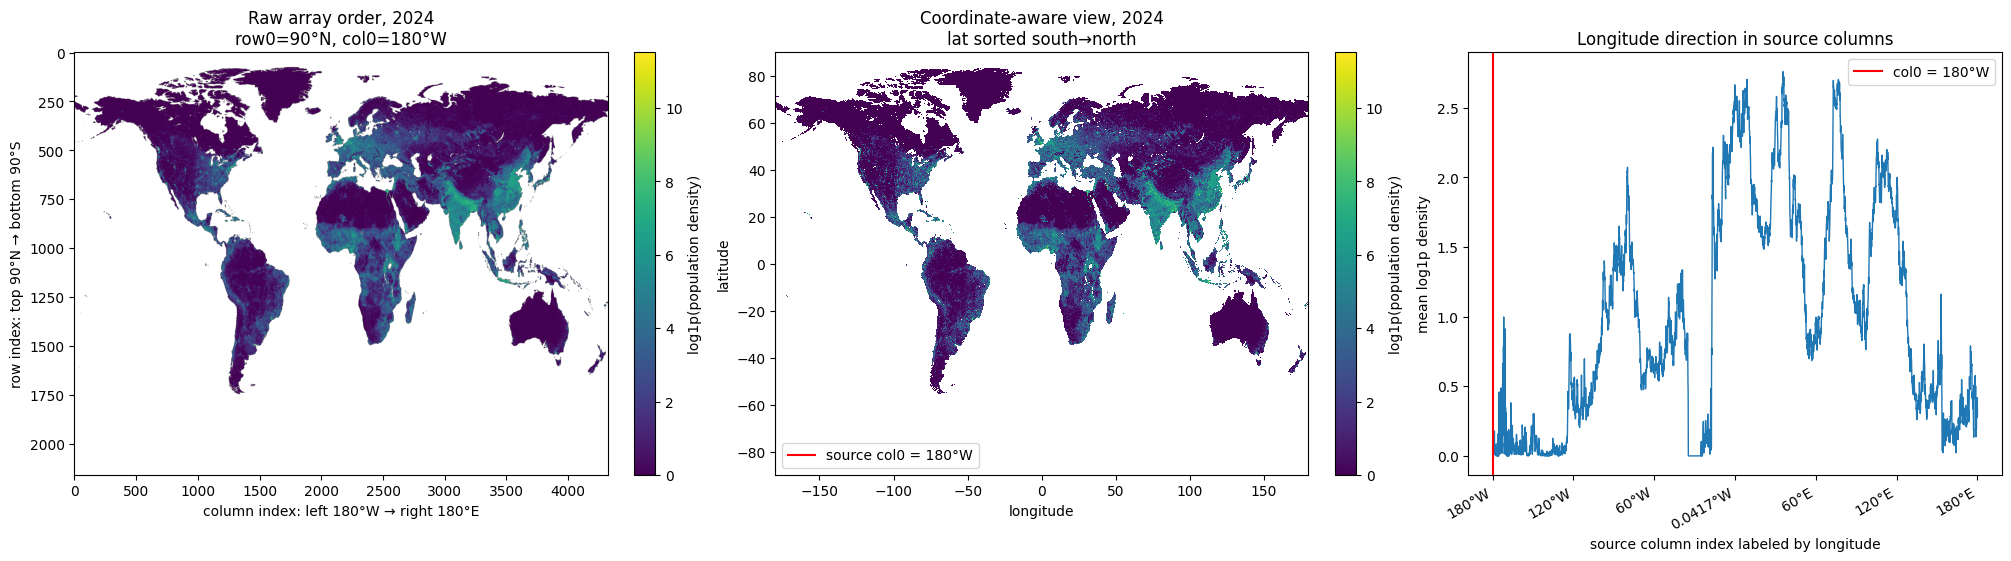

In [12]:
year_to_index = {int(year): int(index) for index, year in enumerate(available_years)}


def get_year_slice(year):
    if int(year) not in year_to_index:
        raise KeyError(f"year {year} is not available")
    sub = da.isel({TIME_DIM: year_to_index[int(year)]}).squeeze(drop=True)
    return sub.transpose(LAT_DIM, LON_DIM)


latest_year = int(np.nanmax(available_years))
plot_year = latest_year
arr_da = get_year_slice(plot_year)
arr = np.asarray(arr_da.values, dtype=float)
arr_for_plot = np.where(arr < 0, np.nan, arr)
arr_for_plot = np.log1p(arr_for_plot)

lat_order = np.argsort(lat_values)
lon_order = np.argsort(lon_values)
lat_plot = lat_values[lat_order]
lon_plot = lon_values[lon_order]
arr_geo = arr_for_plot[np.ix_(lat_order, lon_order)]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), constrained_layout=True)

im0 = axes[0].imshow(arr_for_plot, origin="upper", aspect="auto")
axes[0].set_title(f"Raw array order, {plot_year}\nrow0={lat_label(lat_values[0])}, col0={lon_label(lon_values[0])}")
axes[0].set_xlabel(f"column index: left {lon_label(lon_values[0])} → right {lon_label(lon_values[-1])}")
axes[0].set_ylabel(f"row index: top {lat_label(lat_values[0])} → bottom {lat_label(lat_values[-1])}")
fig.colorbar(im0, ax=axes[0], label="log1p(population density)")

im1 = axes[1].pcolormesh(lon_plot, lat_plot, arr_geo, shading="auto")
axes[1].axvline(lon_values[0], color="red", linewidth=1.5, label=f"source col0 = {lon_label(lon_values[0])}")
axes[1].set_title(f"Coordinate-aware view, {plot_year}\nlat sorted south→north")
axes[1].set_xlabel("longitude")
axes[1].set_ylabel("latitude")
axes[1].legend(loc="lower left")
fig.colorbar(im1, ax=axes[1], label="log1p(population density)")

col_profile = np.nanmean(arr_for_plot, axis=0)
x = np.arange(lon_values.size)
axes[2].plot(x, col_profile, linewidth=1)
axes[2].axvline(0, color="red", linewidth=1.5, label=f"col0 = {lon_label(lon_values[0])}")
tick_idx = np.unique(np.linspace(0, lon_values.size - 1, 7).astype(int))
axes[2].set_xticks(tick_idx)
axes[2].set_xticklabels([lon_label(lon_values[i]) for i in tick_idx], rotation=30, ha="right")
axes[2].set_title("Longitude direction in source columns")
axes[2].set_xlabel("source column index labeled by longitude")
axes[2].set_ylabel("mean log1p density")
axes[2].legend(loc="best")

plt.show()

In [13]:
def orient_for_save(data2d):
    data_out = np.asarray(data2d, dtype=OUTPUT_DTYPE)
    lat_out = lat_values.copy()
    lon_out = lon_values.copy()

    if SAVE_EXACT_SOURCE_ORDER:
        return data_out, lat_out, lon_out, "source_order"

    # row 0 = north、columnは -180..180 の west→east に標準化する。
    orientation = "standardized_row0_north_lon_minus180_to_180_west_to_east"

    if lat_out[0] < lat_out[-1]:
        data_out = data_out[::-1, :]
        lat_out = lat_out[::-1]

    lon_norm = ((lon_out + 180.0) % 360.0) - 180.0
    lon_order_for_save = np.argsort(lon_norm)
    data_out = data_out[:, lon_order_for_save]
    lon_out = lon_norm[lon_order_for_save]

    return data_out, lat_out, lon_out, orientation


latest_year = int(np.nanmax(available_years))
end_year = latest_year if END_YEAR is None else min(int(END_YEAR), latest_year)

target_years = np.arange(int(START_YEAR), int(end_year) + 1, dtype=int)
present_mask = np.isin(target_years, available_years.astype(int))
missing_years = target_years[~present_mask]
target_years = target_years[present_mask]

if missing_years.size:
    warnings.warn(
        f"{missing_years.size} requested years are not available and will be skipped. "
        f"first_missing={missing_years[:10].tolist()}"
    )

if target_years.size == 0:
    raise ValueError(f"no available years in requested range: {START_YEAR}..{end_year}")

print(f"saving years: {target_years[0]} .. {target_years[-1]} ({len(target_years)} files)")

saved_paths = []
stack_arrays = []
lat_saved = None
lon_saved = None
save_orientation = None

for number, year in enumerate(target_years, start=1):
    out_path = OUT_DIR / f"{NC_PATH.stem}_{int(year)}.npy"
    if out_path.exists() and not OVERWRITE:
        print(f"skip existing: {out_path.name}")
        saved_paths.append(out_path)
        continue

    year_data = get_year_slice(int(year)).values
    data_out, lat_out, lon_out, save_orientation = orient_for_save(year_data)

    np.save(out_path, data_out)
    saved_paths.append(out_path)

    if lat_saved is None:
        lat_saved = lat_out
        lon_saved = lon_out

    if SAVE_STACK_FILE:
        stack_arrays.append(data_out)

    if number == 1 or number == len(target_years) or number % 10 == 0:
        print(f"[{number:>3}/{len(target_years)}] saved {out_path.name} shape={data_out.shape} dtype={data_out.dtype}")

lat_path = OUT_DIR / f"{NC_PATH.stem}_lat.npy"
lon_path = OUT_DIR / f"{NC_PATH.stem}_lon.npy"
years_path = OUT_DIR / f"{NC_PATH.stem}_years.npy"
np.save(lat_path, lat_saved)
np.save(lon_path, lon_saved)
np.save(years_path, target_years.astype(np.int16))

metadata = {
    "source_nc": str(NC_PATH),
    "variable": str(VAR_NAME),
    "saved_year_start": int(target_years[0]),
    "saved_year_end": int(target_years[-1]),
    "saved_year_count": int(len(target_years)),
    "output_dtype": OUTPUT_DTYPE,
    "save_orientation": save_orientation,
    "source_lat_first": float(lat_values[0]),
    "source_lat_last": float(lat_values[-1]),
    "source_lon_first": float(lon_values[0]),
    "source_lon_last": float(lon_values[-1]),
    "npy_shape": list(data_out.shape),
    "year_file_pattern": f"{NC_PATH.stem}_YYYY.npy",
    "lat_file": lat_path.name,
    "lon_file": lon_path.name,
    "years_file": years_path.name,
}
metadata_path = OUT_DIR / f"{NC_PATH.stem}_npy_metadata.json"
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

if SAVE_STACK_FILE:
    stack = np.stack(stack_arrays, axis=0).astype(OUTPUT_DTYPE, copy=False)
    stack_path = OUT_DIR / f"{NC_PATH.stem}_{int(target_years[0])}_{int(target_years[-1])}_stack.npy"
    np.save(stack_path, stack)
    metadata["stack_file"] = stack_path.name
    metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"saved stack: {stack_path}")

print(f"saved lat  : {lat_path}")
print(f"saved lon  : {lon_path}")
print(f"saved years: {years_path}")
print(f"metadata   : {metadata_path}")

saving years: 1950 .. 2024 (75 files)
[  1/75] saved population_density_1950.npy shape=(2160, 4320) dtype=float32
[ 10/75] saved population_density_1959.npy shape=(2160, 4320) dtype=float32
[ 20/75] saved population_density_1969.npy shape=(2160, 4320) dtype=float32
[ 30/75] saved population_density_1979.npy shape=(2160, 4320) dtype=float32
[ 40/75] saved population_density_1989.npy shape=(2160, 4320) dtype=float32
[ 50/75] saved population_density_1999.npy shape=(2160, 4320) dtype=float32
[ 60/75] saved population_density_2009.npy shape=(2160, 4320) dtype=float32
[ 70/75] saved population_density_2019.npy shape=(2160, 4320) dtype=float32
[ 75/75] saved population_density_2024.npy shape=(2160, 4320) dtype=float32
saved lat  : C:\masterresearch\Comparative_advantage\HYDE3.4\population_density_npy\population_density_lat.npy
saved lon  : C:\masterresearch\Comparative_advantage\HYDE3.4\population_density_npy\population_density_lon.npy
saved years: C:\masterresearch\Comparative_advantage\HYD

In [14]:
# 保存結果の簡易確認
sample_path = OUT_DIR / f"{NC_PATH.stem}_{int(target_years[0])}.npy"
sample = np.load(sample_path)
print(sample_path)
print("shape:", sample.shape, "dtype:", sample.dtype, "min:", np.nanmin(sample), "max:", np.nanmax(sample))
print("lat:", np.load(lat_path).shape, np.load(lat_path)[0], "...", np.load(lat_path)[-1])
print("lon:", np.load(lon_path).shape, np.load(lon_path)[0], "...", np.load(lon_path)[-1])
print("years:", np.load(years_path)[0], "...", np.load(years_path)[-1])

C:\masterresearch\Comparative_advantage\HYDE3.4\population_density_npy\population_density_1950.npy
shape: (2160, 4320) dtype: float32 min: 0.0 max: 49749.95
lat: (2160,) 89.95825958251953 ... -89.95833587646484
lon: (4320,) -179.9583282470703 ... 179.95819091796875
years: 1950 ... 2024
